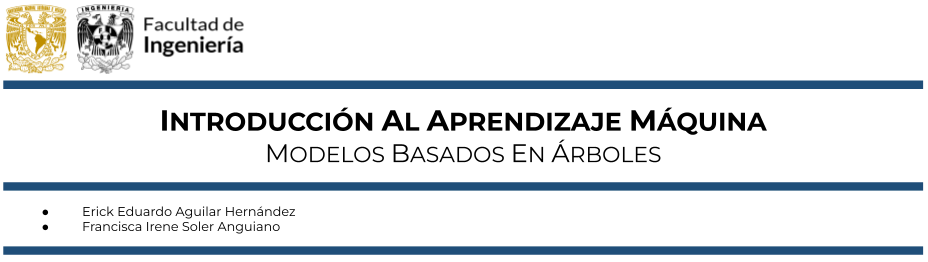

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 7.4.1 — Implementación: bosques de aislamiento
___


### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para estudiar **bosques de aislamiento** como método de detección de anomalías. Además de las herramientas usuales para manipular datos y producir visualizaciones, se prepara el entorno gráfico con `ggplot`. En este notebook el objetivo no es predecir una etiqueta conocida, sino identificar observaciones inusuales a partir de las relaciones entre variables numéricas.


In [1]:
from sklearn.model_selection import train_test_split
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

## Conjunto de datos: Palmer Penguins

Para ilustrar el funcionamiento de los Bosques de Aislamiento utilizaremos nuevamente el conjunto de datos de los pingüinos (\textit{Palmer Penguins}), el cual ha sido empleado en capítulos anteriores. En esta ocasión nos centraremos únicamente en la especie **Gentoo**, cuyas características morfológicas presentan una distribución relativamente homogénea, lo que facilita la identificación de observaciones con un comportamiento atípico.

A diferencia de los algoritmos estudiados previamente, en este ejemplo no se utilizará ninguna variable objetivo. El Bosque de Aislamiento es un método de aprendizaje no supervisado que identifica observaciones inusuales a partir de sus características, sin requerir etiquetas de entrenamiento. Para ello, emplearemos las variables numéricas disponibles en el conjunto de datos y analizaremos cuáles individuos son detectados como posibles anomalías por el modelo.

### Variables analizadas

| Variable | Descripción |
|----------|-------------|
| `bill_length_mm` | Longitud del pico, medida en milímetros. |
| `bill_depth_mm` | Profundidad del pico, medida en milímetros. |
| `flipper_length_mm` | Longitud de la aleta, medida en milímetros. |
| `body_mass_g` | Masa corporal del pingüino, expresada en gramos. |

### Carga local del conjunto Palmer Penguins

Se carga el conjunto **Palmer Penguins** desde el archivo `penguins.csv` guardado en el directorio `datos`. Al leer el archivo localmente se evita depender de descargas externas durante la ejecución del notebook. La columna `year` se elimina porque no se usará en el análisis, y las demás columnas se conservan para seleccionar posteriormente las variables morfológicas que alimentarán al bosque de aislamiento.


In [2]:
data_paths = [Path("datos") / "penguins.csv", Path("..") / "datos" / "penguins.csv"]
data_path = next(path for path in data_paths if path.exists())
penguins_data_df = pd.read_csv(data_path).drop(columns=["year"])
feature_names = penguins_data_df.drop(columns="species").columns.tolist()
penguins_data_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


### Exploración de la especie Gentoo

El análisis se restringe a los pingüinos de la especie **Gentoo**. Esta decisión hace que la detección de anomalías sea más interpretable, porque las observaciones se comparan contra individuos de una misma especie y no contra grupos con morfologías naturalmente distintas. El `pairplot` permite revisar visualmente las relaciones entre las variables numéricas y detectar, de manera exploratoria, puntos que podrían encontrarse alejados del patrón central de la especie.


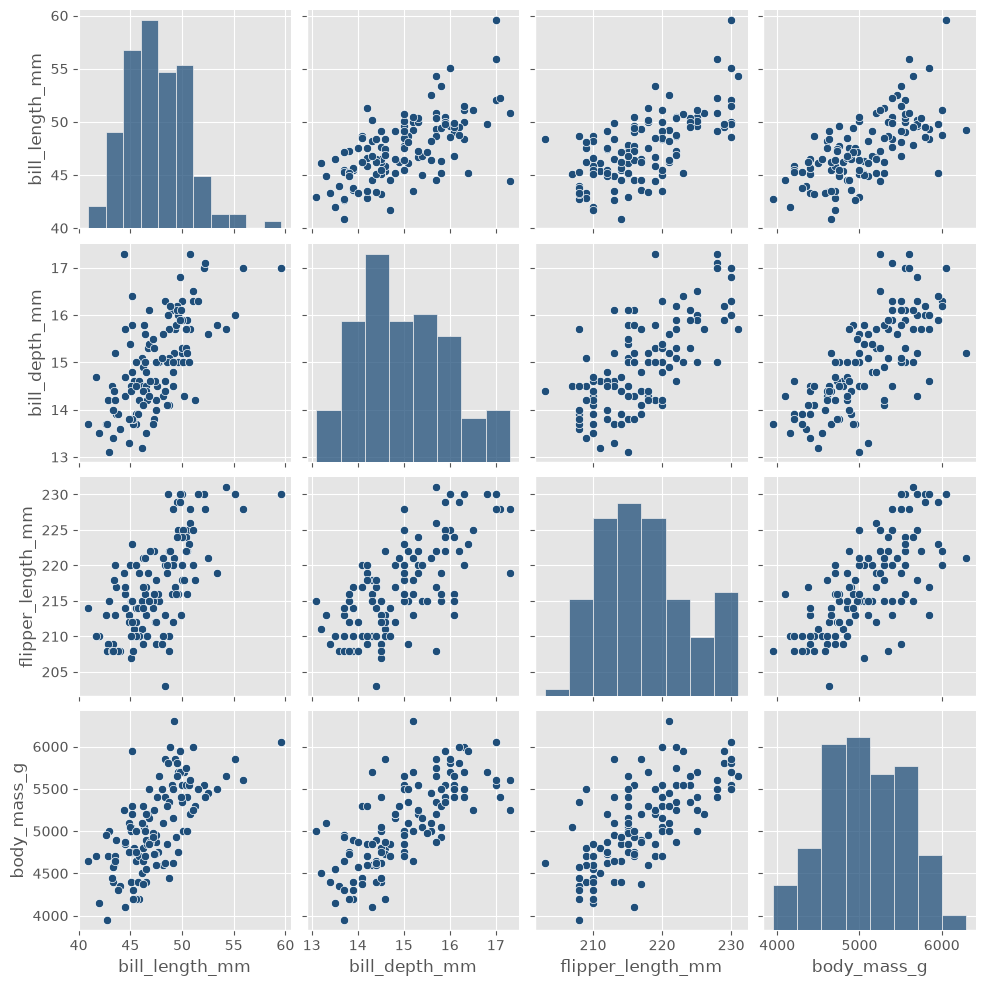

In [3]:
gentoo_df = penguins_data_df[penguins_data_df['species']=='Gentoo']
sns.pairplot(
    gentoo_df,
    plot_kws={"color": "#1F4E79"},
    diag_kws={"color": "#1F4E79"}
)

### Ajuste del bosque de aislamiento

Se ajusta un `IsolationForest` usando únicamente variables morfológicas numéricas: longitud y profundidad del pico, longitud de la aleta y masa corporal. El bosque de aislamiento funciona separando observaciones mediante particiones aleatorias; las observaciones atípicas suelen aislarse con menos particiones porque se encuentran en regiones menos densas del espacio de variables. El parámetro `contamination=0.05` indica que se espera detectar alrededor del 5% de las observaciones como posibles anomalías.


In [4]:
from sklearn.ensemble import IsolationForest

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = gentoo_df[features]

gentoo_outlier_detector = IsolationForest(
    contamination=0.05,
    random_state=42
).fit(X)

### Puntaje de anomalía y clasificación inlier/outlier

Una vez ajustado el modelo, `score_samples` asigna a cada observación un puntaje de anomalía. En `scikit-learn`, valores más bajos suelen indicar observaciones más anómalas. La función `predict` clasifica cada punto como `1` para observaciones normales (*inliers*) y `-1` para observaciones atípicas (*outliers*). Esta tabla permite revisar qué individuos fueron señalados por el modelo y comparar su puntaje contra sus características morfológicas.


In [5]:
gentoo_df["Anomaly_score"] =  gentoo_outlier_detector.score_samples(X)
gentoo_df["Anomaly"] = gentoo_outlier_detector.predict(X)
gentoo_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Anomaly_score,Anomaly
152,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,female,-0.489592,1
153,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,male,-0.481151,1
154,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,female,-0.468498,1
155,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,male,-0.436909,1
156,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,male,-0.421096,1
...,...,...,...,...,...,...,...,...,...
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,-0.673502,-1
272,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,female,-0.402551,1
273,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,male,-0.446976,1
274,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,female,-0.415976,1


### Visualización multivariada de anomalías

Esta visualización repite el `pairplot`, pero ahora colorea las observaciones según la etiqueta producida por el bosque de aislamiento. Los puntos azules representan observaciones consideradas normales y los puntos rojos representan posibles anomalías. La gráfica ayuda a interpretar si los outliers aparecen alejados en una sola variable o si su rareza surge de combinaciones poco comunes entre varias características.


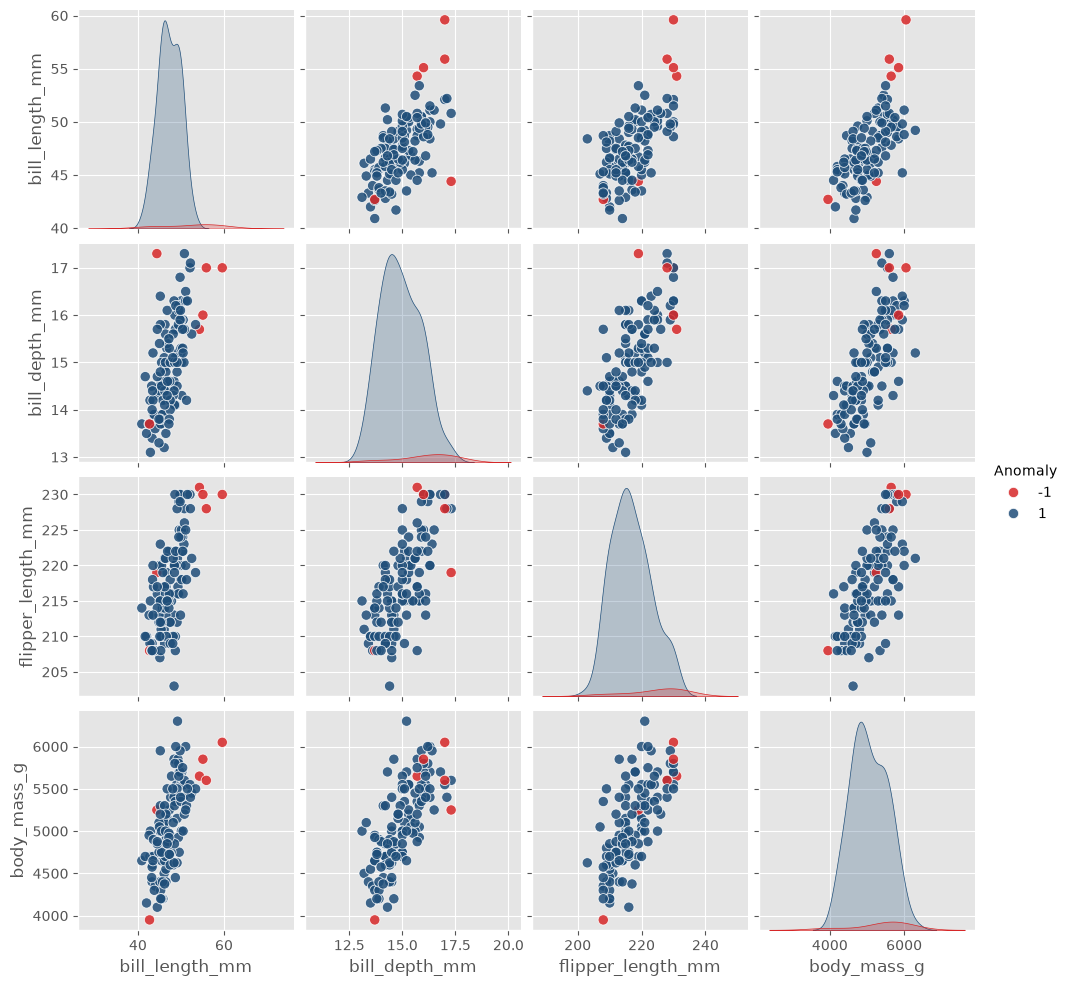

In [6]:
palette = {
    1: "#1F4E79",   # Azul petróleo
    -1: "#D62728"   # Rojo
}

sns.pairplot(
    gentoo_df[features + ['Anomaly']],
    hue="Anomaly",
    palette=palette,
    plot_kws={"s": 55, "alpha": 0.85}
)

### Distribución del puntaje de anomalía

El boxplot y los puntos superpuestos muestran la distribución de `Anomaly_score` para la especie Gentoo. Las observaciones normales se presentan en azul y las anomalías en rojo. Esta gráfica complementa el análisis multivariado: permite ver qué tan separados están los outliers en términos del puntaje asignado por el modelo y ayuda a interpretar si las anomalías detectadas son claramente extremas o se encuentran cerca del límite de decisión.


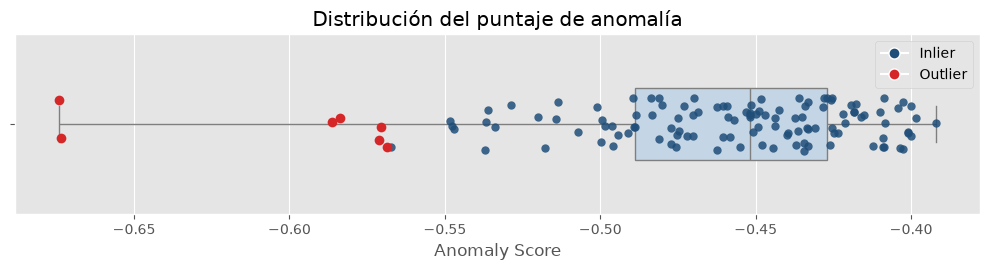

In [7]:
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 2.8))

sns.boxplot(
    data=gentoo_df,
    x="Anomaly_score",
    color="#BFD7EA",
    width=0.4,
    whis=[0, 100],
    fliersize=0
)

sns.stripplot(
    data=gentoo_df[gentoo_df["Anomaly"] == 1],
    x="Anomaly_score",
    color="#1F4E79",
    size=6,
    alpha=0.85,
    jitter=0.15
)

sns.stripplot(
    data=gentoo_df[gentoo_df["Anomaly"] == -1],
    x="Anomaly_score",
    color="#D62728",
    size=7,
    alpha=1,
    jitter=0.15
)

legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#1F4E79", markersize=8,
           label="Inlier"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#D62728", markersize=8,
           label="Outlier")
]

plt.legend(handles=legend, loc="upper right")
plt.xlabel("Anomaly Score")
plt.ylabel("")
plt.title("Distribución del puntaje de anomalía")
plt.tight_layout()
plt.show()